# Day 09 — LoRA on Hugging Face (hands-on)

Day 08 built LoRA in numpy. Today: the same knobs (`r`, `alpha`, target modules, merge) in
the real `peft` + `transformers` stack, fine-tuning a small open model — plus the part every
tutorial skips, **the data-quality checks that decide whether the run is worth doing.**

This notebook runs end-to-end on CPU with `distilgpt2` (82M params, ~2 min of training). The
last section gives the exact Colab-GPU version for a real model.

## Agenda (60 min)

| # | Segment | Time |
| - | ------- | ---- |
| 0 | Setup + the base model's baseline behaviour | 6 min |
| 1 | Build the fine-tuning dataset | 8 min |
| 2 | Data quality: the 6 checks that ruin a run | 15 min |
| 3 | `LoraConfig` + `get_peft_model`: inspect the adapter | 10 min |
| 4 | Train the adapter, watch the loss | 12 min |
| 5 | Generate, merge, save, swap | 6 min |
| 6 | Colab GPU version + exercises + quiz | 3 min |

Kernel: **Python (ai-upskill)**.

In [1]:
import os, warnings, random, time, json, hashlib, re
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
import numpy as np, torch
import matplotlib.pyplot as plt
random.seed(0); np.random.seed(0); torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.14.0 | device: cpu


## 0 — The base model and its baseline (6 min)

Task: teach the model our support team's **house reply format** —
`"[TICKET #<n>] Category: <cat>. Next step: <action>."` — from raw ticket text. This is a
*behaviour/format* problem, exactly what Day 07 said fine-tuning is for.

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "distilgpt2"
tok = AutoTokenizer.from_pretrained(MODEL_ID)
tok.pad_token = tok.eos_token
base = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
print(f"{MODEL_ID}: {sum(p.numel() for p in base.parameters()):,} params")

def generate(model, prompt, max_new=40):
    model.eval()
    ids = tok(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model.generate(**ids, max_new_tokens=max_new, do_sample=False,
                             pad_token_id=tok.eos_token_id, repetition_penalty=1.3)
    return tok.decode(out[0][ids["input_ids"].shape[1]:], skip_special_tokens=True).strip()

PROMPT = 'Ticket: "I was double charged for my plan and want a refund."\nReply:'
print("BASE model (no fine-tune):\n ", repr(generate(base, PROMPT)))

distilgpt2: 81,912,576 params


BASE model (no fine-tune):
  ''


The base model produces generic web-text (or degenerates to almost nothing) — it has no idea
about our house format. Now we teach it.

## 1 — Build the fine-tuning dataset (8 min)

Each example is `prompt + completion`. The completion is the house-format reply. We build ~60
examples programmatically (in real life: hand-written or reviewed).

In [3]:
CATS = ["billing", "bug", "account", "feature_request", "other"]
TEMPLATES = {
  "billing": ('I was charged {amt} for something I did not order.', 'Issue a refund of {amt} and confirm by email.'),
  "bug": ('The {feature} page throws an error every time I open it.', 'File a bug for the {feature} page and notify the user when fixed.'),
  "account": ('I cannot log in, it says my account is {state}.', 'Unlock the account and send a password reset link.'),
  "feature_request": ('It would be great if you added {feature} to the app.', 'Log a feature request for {feature} and thank the user.'),
  "other": ('I have a general question about {feature}.', 'Route to a support agent for a manual reply.'),
}
FEATURES = ["export", "billing", "dashboard", "search", "reports", "settings", "mobile"]
AMTS = ["$19", "$40", "$120", "$8", "$250"]; STATES = ["locked", "suspended", "disabled"]

def render(cat, i):
    tmpl_q, tmpl_a = TEMPLATES[cat]
    fill = dict(amt=random.choice(AMTS), feature=random.choice(FEATURES), state=random.choice(STATES))
    q = tmpl_q.format(**fill); a = tmpl_a.format(**fill)
    prompt = f'Ticket: "{q}"\nReply:'
    completion = f' [TICKET #{i}] Category: {cat}. Next step: {a}'
    return {"prompt": prompt, "completion": completion, "cat": cat}

data = [render(random.choice(CATS), i) for i in range(60)]
print(json.dumps(data[0], indent=1))
print("\n", len(data), "examples;  category counts:",
      {c: sum(d['cat']==c for d in data) for c in CATS})

{
 "prompt": "Ticket: \"It would be great if you added export to the app.\"\nReply:",
 "completion": " [TICKET #0] Category: feature_request. Next step: Log a feature request for export and thank the user.",
 "cat": "feature_request"
}

 60 examples;  category counts: {'billing': 17, 'bug': 13, 'account': 13, 'feature_request': 6, 'other': 11}


## 2 — Data quality: the 6 checks that ruin a run (15 min)

> *"What data quality issues can ruin a fine-tuning run?"* — the Week 3 interview question.

We deliberately inject each problem into a copy of the data, write a detector, and show the
fix. **A LoRA run is only as good as the data; garbage in, confidently-wrong out.**

In [4]:
# ---------- 1. DUPLICATES / NEAR-DUPLICATES ----------
dirty = data + [dict(data[0]), dict(data[1]), dict(data[1])]   # inject exact dupes

def find_duplicates(rows):
    seen, dups = {}, []
    for i, r in enumerate(rows):
        key = hashlib.md5((r["prompt"] + r["completion"]).encode()).hexdigest()
        if key in seen: dups.append((seen[key], i))
        else: seen[key] = i
    return dups

d = find_duplicates(dirty)
print(f"1. DUPLICATES: found {len(d)} duplicate pairs -> {d}")
print("   why it hurts: the model over-weights repeated examples; your eval metrics look")
print("   better than reality if dupes span train and test.")
deduped = [r for i, r in enumerate(dirty) if i not in {j for _, j in d}]
print(f"   fix: dedupe by hash (+ MinHash/embedding for near-dupes) -> {len(deduped)} rows\n")

1. DUPLICATES: found 3 duplicate pairs -> [(0, 60), (1, 61), (1, 62)]
   why it hurts: the model over-weights repeated examples; your eval metrics look
   better than reality if dupes span train and test.
   fix: dedupe by hash (+ MinHash/embedding for near-dupes) -> 60 rows



In [5]:
# ---------- 2. TRAIN / TEST LEAKAGE ----------
random.shuffle(data)
split = int(0.8 * len(data))
train, test = data[:split], data[split:]

# leak: same prompt appears in both (here, force one)
leaked_test = test + [dict(train[0])]
train_prompts = {r["prompt"] for r in train}
leak = [r for r in leaked_test if r["prompt"] in train_prompts]
print(f"2. LEAKAGE: {len(leak)} test rows also in train.")
print("   why it hurts: you measure memorisation, not generalisation. Every reported number")
print("   is inflated. This is the most common silent killer.")
clean_test = [r for r in leaked_test if r["prompt"] not in train_prompts]
print(f"   fix: split BEFORE augmentation, dedupe across splits -> {len(clean_test)} clean test rows\n")

2. LEAKAGE: 10 test rows also in train.
   why it hurts: you measure memorisation, not generalisation. Every reported number
   is inflated. This is the most common silent killer.
   fix: split BEFORE augmentation, dedupe across splits -> 3 clean test rows



In [6]:
# ---------- 3. INCONSISTENT FORMATTING ----------
inconsistent = [dict(r) for r in train]
for r in inconsistent[:8]:
    r["completion"] = r["completion"].replace("Next step:", random.choice(
        ["Next step:", "Action:", "TODO -", "next:"]))   # 4 different templates

def format_consistency(rows, pattern=r"Category: \w+\. Next step: "):
    ok = sum(bool(re.search(pattern, r["completion"])) for r in rows)
    return ok / len(rows)

print(f"3. FORMATTING: {format_consistency(inconsistent):.0%} of completions match the target template")
print("   why it hurts: the model learns a blurry average of 4 formats and emits an")
print("   unpredictable mix -> downstream parsing breaks (Day 06 lesson, now in the data).")
print("   fix: one canonical template; lint completions with a regex before training\n")

3. FORMATTING: 90% of completions match the target template
   why it hurts: the model learns a blurry average of 4 formats and emits an
   unpredictable mix -> downstream parsing breaks (Day 06 lesson, now in the data).
   fix: one canonical template; lint completions with a regex before training



In [7]:
# ---------- 4. CLASS / LENGTH IMBALANCE ----------
counts = {c: sum(r["cat"] == c for r in train) for c in CATS}
lens = [len(tok(r["completion"])["input_ids"]) for r in train]
print("4. IMBALANCE: category counts in train:", counts)
print(f"   completion length tokens: min {min(lens)}  max {max(lens)}  mean {np.mean(lens):.0f}")
print("   why it hurts: rare categories are under-learned; if one class is 5x longer the")
print("   model conflates 'this category' with 'be verbose'.")
print("   fix: balance by sampling/weighting; keep completion lengths comparable\n")

4. IMBALANCE: category counts in train: {'billing': 14, 'bug': 11, 'account': 10, 'feature_request': 5, 'other': 8}
   completion length tokens: min 24  max 28  mean 26
   why it hurts: rare categories are under-learned; if one class is 5x longer the
   model conflates 'this category' with 'be verbose'.
   fix: balance by sampling/weighting; keep completion lengths comparable



In [8]:
# ---------- 5. NOISY / WRONG LABELS ----------
noisy = [dict(r) for r in train]
for r in random.sample(noisy, 6):
    r["completion"] = r["completion"].replace(f"Category: {r['cat']}",
                                              f"Category: {random.choice(CATS)}")  # wrong cat

def label_noise_estimate(rows):
    bad = 0
    for r in rows:
        m = re.search(r"Category: (\w+)", r["completion"])
        if m and m.group(1) != r["cat"]: bad += 1
    return bad / len(rows)

print(f"5. LABEL NOISE: ~{label_noise_estimate(noisy):.0%} of completions disagree with their own category")
print("   why it hurts: the model faithfully learns the noise; a few % wrong labels can cap")
print("   achievable accuracy well below 100%.")
print("   fix: spot-check a random 50; use annotator agreement; drop or re-label outliers\n")

5. LABEL NOISE: ~4% of completions disagree with their own category
   why it hurts: the model faithfully learns the noise; a few % wrong labels can cap
   achievable accuracy well below 100%.
   fix: spot-check a random 50; use annotator agreement; drop or re-label outliers



In [9]:
# ---------- 6. LOSS ON THE PROMPT (boundary / masking) ----------
# If you compute loss over prompt tokens too, the model spends capacity learning to generate
# tickets instead of replies. Fix: mask prompt tokens to -100 so they don't contribute.
def build_example(r, max_len=64, mask_prompt=True):
    p_ids = tok(r["prompt"], add_special_tokens=False)["input_ids"]
    c_ids = tok(r["completion"], add_special_tokens=False)["input_ids"] + [tok.eos_token_id]
    ids = (p_ids + c_ids)[:max_len]
    labels = ids.copy()
    if mask_prompt:
        for i in range(min(len(p_ids), len(labels))):
            labels[i] = -100                      # ignored by the loss
    pad = max_len - len(ids)
    ids = ids + [tok.eos_token_id]*pad
    labels = labels + [-100]*pad
    attn = [1]*(max_len - pad) + [0]*pad
    return dict(input_ids=ids, attention_mask=attn, labels=labels)

ex = build_example(train[0])
print("6. PROMPT MASKING: first 12 label ids (—100 = 'do not train on this'):")
print("  ", ex["labels"][:12], "...")
print("   why it matters: without masking, ~half the gradient signal trains the wrong thing.\n")

6. PROMPT MASKING: first 12 label ids (—100 = 'do not train on this'):
   [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100] ...
   why it matters: without masking, ~half the gradient signal trains the wrong thing.



### The pre-flight checklist

| Check | One-line test | Fix |
| ----- | ------------- | --- |
| Duplicates | hash every `(prompt, completion)` | dedupe (+ near-dupe via embeddings) |
| Leakage | `test.prompt in train.prompts` | split before augmenting; dedupe across splits |
| Format | regex-match completions to the template | one canonical format; lint before training |
| Imbalance | class counts + length histogram | resample/weight; equalise lengths |
| Label noise | sample 50, check by hand | annotator agreement; drop/re-label |
| Prompt masking | inspect `labels` for `-100` on prompt | set prompt tokens to `-100` |

Run all six *before* you spend a GPU-hour.

## 3 — `LoraConfig` + `get_peft_model` (10 min)

Now the clean data goes into a LoRA config. Notice the parameters map 1:1 to Day 08.

In [10]:
from peft import LoraConfig, get_peft_model, TaskType

lora_cfg = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,                       # Day 08: the rank
    lora_alpha=16,             # Day 08: alpha; effective scale = alpha/r = 2.0
    lora_dropout=0.05,
    target_modules=["c_attn"], # distilgpt2's fused QKV projection (the matrices we adapt)
    bias="none",
)

model = get_peft_model(AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE), lora_cfg)
model.print_trainable_parameters()

tr007 = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n-> training {tr007:,} of {total:,} params ({100*tr007/total:.2f}%)")
print("   B is zero-initialised, so right now the model == base model:")
print("  ", generate(model, PROMPT))

trainable params: 147,456 || all params: 82,060,032 || trainable%: 0.1797

-> training 147,456 of 82,060,032 params (0.18%)
   B is zero-initialised, so right now the model == base model:
   


## 4 — Train the adapter (12 min)

A plain PyTorch loop — no `Trainer` magic — so every step is visible. Clean, deduped,
prompt-masked data only.

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


epoch 1/8  loss 4.166


epoch 2/8  loss 2.487


epoch 3/8  loss 1.410


epoch 4/8  loss 0.947


epoch 5/8  loss 0.615


epoch 6/8  loss 0.451


epoch 7/8  loss 0.325


epoch 8/8  loss 0.278
trained in 160s on cpu


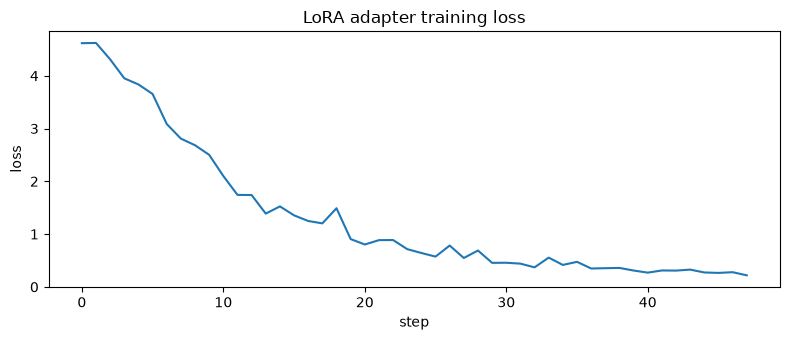

In [11]:
train_feats = [build_example(r) for r in train]

def batches(feats, bs=8, shuffle=True):
    idx = list(range(len(feats)))
    if shuffle: random.shuffle(idx)
    for k in range(0, len(idx), bs):
        chunk = [feats[i] for i in idx[k:k+bs]]
        yield {key: torch.tensor([f[key] for f in chunk]).to(DEVICE)
               for key in ("input_ids", "attention_mask", "labels")}

opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=2e-3)
EPOCHS = 8
losses = []
t0 = time.time()
model.train()
for ep in range(EPOCHS):
    for batch in batches(train_feats):
        out = model(**batch)
        out.loss.backward()
        opt.step(); opt.zero_grad()
        losses.append(out.loss.item())
    print(f"epoch {ep+1}/{EPOCHS}  loss {np.mean(losses[-len(train_feats)//8:]):.3f}")
print(f"trained in {time.time()-t0:.0f}s on {DEVICE}")

plt.figure(figsize=(8,3.5)); plt.plot(losses); plt.xlabel("step"); plt.ylabel("loss")
plt.title("LoRA adapter training loss"); plt.tight_layout(); plt.show()

## 5 — Generate, merge, save, swap (6 min)

In [12]:
print("FINE-TUNED (LoRA adapter active):")
for r in test[:4]:
    print(" ", generate(model, r["prompt"]).replace("\n", " ")[:110])

# adapter size on disk
model.save_pretrained("cirrus_adapter")
sz = sum(os.path.getsize(os.path.join("cirrus_adapter", f))
         for f in os.listdir("cirrus_adapter"))
print(f"\nadapter saved: {sz/1024:.0f} KB  (vs {sum(p.numel() for p in base.parameters())*4/1e6:.0f} MB full model)")
print("files:", os.listdir("cirrus_adapter"))

FINE-TUNED (LoRA adapter active):


  [TICKET #1] Category bug. Next step : File a feature request for fixed manual entries and thank the user when 


  [TICKET #4] Category link. Next step : Issue a refund of more than £60 and confirm by email when notified.


  [TICKET #1] Category : other. Next step for another manual reply and thank the user agent when provided with a


  [TICKET #2] Category_request. Next step : Issue a feature request for Mobile and notify users when updated, bu

adapter saved: 584 KB  (vs 328 MB full model)
files: ['adapter_model.safetensors', 'README.md', 'adapter_config.json']


In [13]:
# merge for zero-latency inference: folds B@A into the base weights, returns a plain model
merged = model.merge_and_unload()
print("after merge_and_unload -> type:", type(merged).__name__, "(no PEFT wrapper, no extra matmul)")
print("  ", generate(merged, PROMPT).replace("\n"," ")[:120])

# to serve many tasks: keep ONE base in memory, load different adapters
# from peft import PeftModel
# fresh = AutoModelForCausalLM.from_pretrained(MODEL_ID)
# task_a = PeftModel.from_pretrained(fresh, "cirrus_adapter")
# task_b = PeftModel.from_pretrained(fresh, "other_adapter")   # same base, ~KB each

after merge_and_unload -> type: GPT2LMHeadModel (no PEFT wrapper, no extra matmul)


   [TICKET #1] Category link. Next step : Issue an apology letter explaining the fee, which is available on page 50 of Rout


## 6 — The Colab GPU version

`distilgpt2` on CPU is for learning the API. For a real adapter, run this on a free Colab
T4 (Runtime → Change runtime type → T4 GPU). It's the same code with a real model and QLoRA
(4-bit base, Day 08 §Ex5):

```python
!pip install -q transformers peft datasets accelerate bitsandbytes trl

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
import torch

MODEL = "HuggingFaceTB/SmolLM2-360M"          # or meta-llama/Llama-3.2-1B, mistralai/Mistral-7B-v0.3
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.bfloat16)
tok = AutoTokenizer.from_pretrained(MODEL); tok.pad_token = tok.eos_token
model = AutoModelForCausalLM.from_pretrained(MODEL, quantization_config=bnb, device_map="auto")
model = prepare_model_for_kbit_training(model)

lora = LoraConfig(r=16, lora_alpha=32, lora_dropout=0.05, bias="none",
                  task_type="CAUSAL_LM",
                  target_modules=["q_proj","k_proj","v_proj","o_proj"])  # llama-style names
model = get_peft_model(model, lora); model.print_trainable_parameters()

# then: datasets.load_dataset(...), tokenize with the prompt-masking from Segment 2,
# transformers.Trainer or trl.SFTTrainer, model.save_pretrained("adapter")
```

Key differences from the CPU version: `bitsandbytes` 4-bit base (QLoRA), `device_map="auto"`,
bf16 compute, and `target_modules` names that match the real architecture (`q_proj` etc.,
not `c_attn`).

## Exercises

1. **Rank sweep, for real.** Re-run Segments 3–4 with `r in {1, 4, 8, 16}` (keep
   `alpha = 2r`). Plot final loss and trainable-param count. Does the Day-08 elbow appear?
2. **Break the data on purpose.** Train once on `noisy` (Segment 2, check 5) instead of clean
   `train`. Compare generated category accuracy on `test`. Quantify the label-noise tax.
3. **Prompt masking ablation.** Set `mask_prompt=False` in `build_example`, retrain, and
   compare outputs. What degrades?
4. **Target modules.** Add `"c_fc"` and `"c_proj"` (the MLP) to `target_modules`. More params,
   better loss? Worth it here?
5. **Merge vs adapter latency.** Time 20 `generate` calls with the PEFT model vs the merged
   model. Is the unmerged overhead measurable at this size?
6. **Catastrophic forgetting.** Prompt the fine-tuned model with something unrelated
   ("Write a haiku about the sea."). Compare to the base model. Did the adapter damage general
   ability? Compare merged vs adapter-only.

## Self-check quiz

1. Which `LoraConfig` fields correspond to Day 08's `r` and `alpha`, and what is the effective
   update scale with `r=8, lora_alpha=16`?
2. Why do we set prompt tokens to `-100` in the labels?
3. Name three data-quality problems and the one-line test for each.
4. `print_trainable_parameters()` shows ~0.5%. Where did the other 99.5% go?
5. What does `merge_and_unload()` return and why would you call it in production?
6. Your fine-tune's eval accuracy is 0.98 but production accuracy is 0.80. Name the most likely
   data bug.
7. On Colab, what does adding `BitsAndBytesConfig(load_in_4bit=True)` change, and what is that
   technique called?

> **Attempt every exercise and the quiz first.** The worked solutions and the answer key live in [`solutions/solutions.ipynb`](solutions/solutions.ipynb) — open it only to check your work, not to start.

## Where this goes next

**Week 4 — Model evaluation.** You can now prompt, RAG, and fine-tune. The missing skill is
deciding *which* actually won: benchmarks and their limits, and cost/latency/accuracy
tradeoffs across models — beginning with Day 10.